<a href="https://colab.research.google.com/github/nterreri-cmu/p2-datacenters/blob/main/electricity_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Findings

#1. Electricity usage over time
Total U.S. electricity sales grew about 7.9%, from about 3.76 million GWh in 2016 to 4.06 million GWh in 2025.
2020 was the lowest point (3.72 million GWh) probably due to COVID. Since then, usage has grown about 9%.
Growth is accelerating: 2025 was up about 2.1% from 2024, one of the largest yearly increases in the period.
Texas (+30.4%) and Virginia (+28.9%) grew far faster than other states from 2016 to 2025. They are also the two states with the most data centers. Utah (+16.2%) and South Dakota (+13.9%) also grew strongly.
Some states were flat or declined, for example Vermont (−0.8%) and Wisconsin (+0.6%).

#2. Customer types
Commercial use grew fastest: +9.2% from 2016 to 2025, with residential +7.5% and industrial +6.7%.
Commercial use fell to its low in 2020 (office closures), then rose every year after, up about 16% from 2020 to 2025.
Commercial’s share of sales has risen every year since 2020, from 34.7% to 36.9% in 2025, the highest share in the period.
Residential’s share peaked in 2020 (39.5%, when people were home) and has fallen back to 37.4%.
Industrial’s share stayed roughly flat at about 26%.

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/nterreri-cmu/p2-datacenters/refs/heads/main/annual_electricity_usage_15-25.csv"
elec_df = pd.read_csv(url)


In [85]:
#EDA
elec_df.shape
elec_df.head()
elec_df.info()
elec_df.isna().sum()
elec_df["period"].value_counts().sort_index()
elec_df["sectorName"].value_counts()
elec_df["stateid"].unique()
elec_df[["customers", "price", "revenue", "sales"]].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3720 entries, 0 to 3719
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   period            3720 non-null   int64  
 1   stateid           3720 non-null   object 
 2   stateDescription  3720 non-null   object 
 3   sectorid          3720 non-null   object 
 4   sectorName        3720 non-null   object 
 5   customers         3720 non-null   int64  
 6   price             3719 non-null   float64
 7   revenue           3719 non-null   float64
 8   sales             3719 non-null   float64
 9   customers-units   3720 non-null   object 
 10  price-units       3720 non-null   object 
 11  revenue-units     3720 non-null   object 
 12  sales-units       3720 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 377.9+ KB


,customers,price,revenue,sales
count,3.720000e+03,3719.000000,3719.000000,3.719000e+03
mean,2.543362e+06,9.184270,7171.579679,6.213635e+04
std,1.153051e+07,6.802483,28704.650507,2.433158e+05
min,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,1.000000e+00,5.850000,1.230720,1.281150e+01
50%,7.625600e+04,9.550000,1144.145700,1.144895e+04
75%,1.437632e+06,12.430000,4716.374350,4.390497e+04
max,1.662106e+08,43.030000,553284.834360,4.058007e+06


In [86]:
#look at only states. remove the national US total and any regional rows (
elec = elec_df[elec_df["stateid"] != "US"]
elec = elec[elec["stateid"].str.len() == 2]
elec["stateid"].nunique()

51

In [87]:
#total US usage by year
total = elec[elec["sectorName"] == "all sectors"]

us_by_year = total.groupby("period")["sales"].sum()
us_by_year

,sales
period,
2016,3.762462e+06
2017,3.723356e+06
2018,3.859185e+06
2019,3.811150e+06
2020,3.717674e+06
2021,3.805874e+06
2022,3.927169e+06
2023,3.874253e+06
2024,3.975382e+06


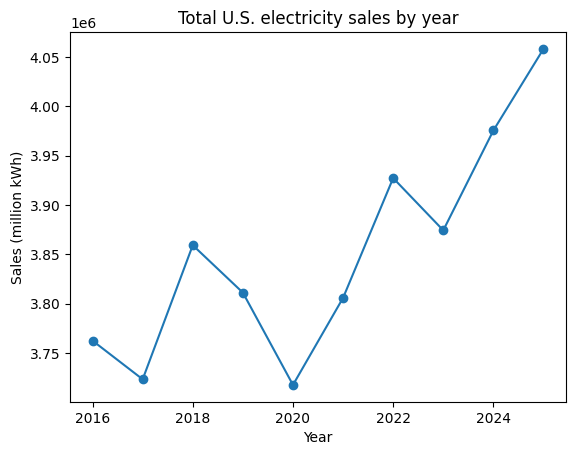

In [88]:
us_by_year.plot(marker="o")
plt.title("Total U.S. electricity sales by year")
plt.xlabel("Year")
plt.ylabel("Sales (million kWh)")
plt.show()

In [89]:
#Usage over time by state
by_state = total.pivot_table(index="period", columns="stateid", values="sales")
by_state.head()


stateid,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
period,,,,,,,,,,,,,,,,,,,,,
2016,6123.20202,88225.14100,46188.43800,78237.82802,256846.63497,54802.03698,28931.08700,11394.003,11258.43800,235721.82200,...,12129.53002,100758.43902,398661.80878,30179.53403,112280.66501,5516.45001,88885.31600,69736.33799,32076.14599,16554.87000
2017,6185.79900,86241.73001,46085.95101,77646.26201,257267.93701,54830.18600,28135.52999,10916.446,11128.60301,233154.54900,...,12313.67503,97239.88499,401880.37401,30589.02102,111529.73201,5423.66200,91948.17201,69079.10897,31709.01900,16778.06699
2018,5972.46698,90280.45600,49602.70798,78346.30199,255224.27197,56450.48002,28833.92500,11357.910,11773.10000,238565.39100,...,12856.93799,102911.18299,424418.62800,31242.40800,118166.34802,5530.94799,90005.79099,70959.54899,33646.81300,16864.67799
2019,5818.80503,88095.11201,48093.03199,77929.17002,250378.71000,56520.82299,27899.99600,11028.403,11469.42199,240347.95505,...,12868.93098,99829.09999,429343.40401,31142.56502,118435.37999,5427.66399,91052.79598,69157.53999,33247.01300,16763.49601
2020,5917.57699,83395.60502,45851.00301,81960.07401,250174.67203,56050.26399,27113.67300,9785.775,11129.05101,242440.17099,...,12695.84499,95003.88798,426863.26697,31663.15699,117254.38800,5331.45801,86706.14400,67448.36105,32076.58300,15331.01800


In [90]:
#states with highest growth in electrcity sale
growth = (by_state.loc[2025] / by_state.loc[2016] - 1) * 100
ggrowth = growth.sort_values(ascending=False).round(1)
ggrowth.head(10)

,0
stateid,
ND,63.8
NM,37.1
TX,30.4
OR,30.0
VA,28.9
NE,24.6
OK,22.1
IA,20.9
AZ,17.0


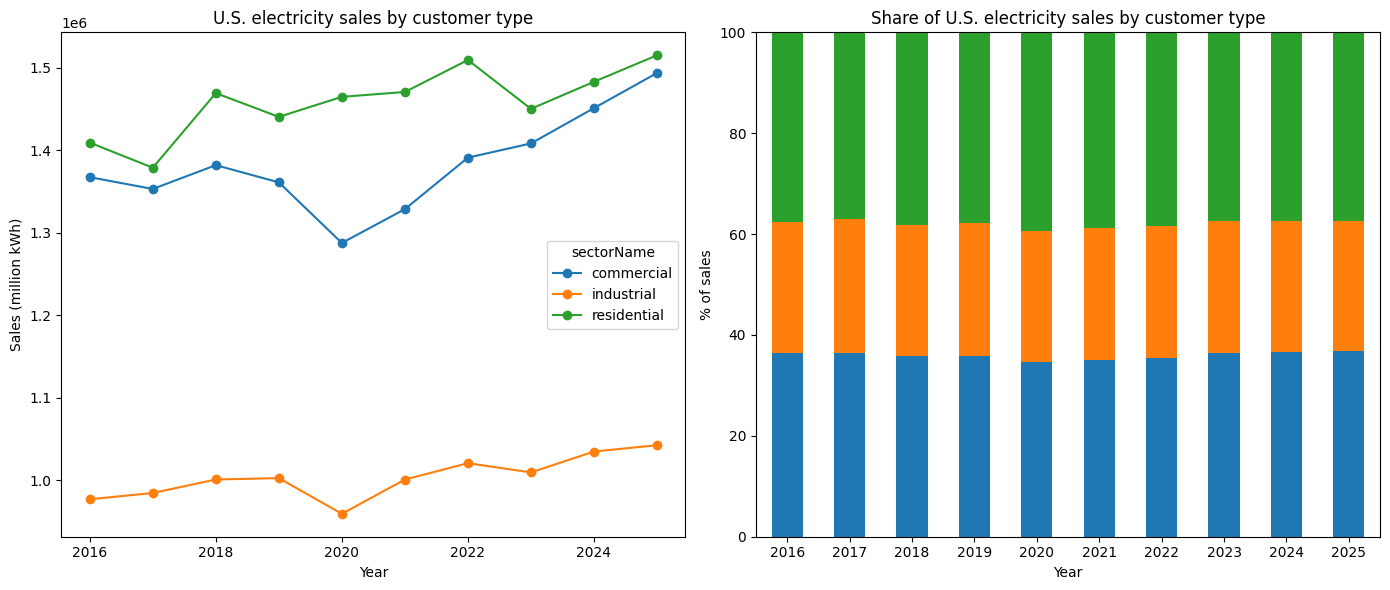

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: sales by customer type
type_by_year.plot(marker="o", ax=axes[0])
axes[0].set_title("U.S. electricity sales by customer type")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Sales (million kWh)")

# Right: share by customer type
share.plot(kind="bar", stacked=True, ax=axes[1], legend=False)
axes[1].set_title("Share of U.S. electricity sales by customer type")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% of sales")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("customer_type_side_by_side.png", dpi=300, bbox_inches="tight")
plt.show()

##Customer Type Comparisons

In [92]:
#dropp "all sectors", "transportation" and "other" since they are either very small or aggregations
types = elec[elec["sectorName"].isin(["residential", "commercial", "industrial"])]

In [93]:

#U.S. usage by customer type over time
type_by_year = types.pivot_table(index="period", columns="sectorName", values="sales", aggfunc="sum")
type_by_year

sectorName,commercial,industrial,residential
period,,,
2016,1.367191e+06,9.767152e+05,1.409052e+06
2017,1.352888e+06,9.842979e+05,1.378648e+06
2018,1.381755e+06,1.000673e+06,1.469093e+06
2019,1.360877e+06,1.002353e+06,1.440289e+06
2020,1.287440e+06,9.590820e+05,1.464605e+06
2021,1.328439e+06,1.000613e+06,1.470487e+06
2022,1.390873e+06,1.020464e+06,1.509233e+06
2023,1.408109e+06,1.009256e+06,1.450025e+06
2024,1.450941e+06,1.034584e+06,1.482874e+06


In [94]:
#Share of each customer type
share = type_by_year.div(type_by_year.sum(axis=1), axis=0) * 100
share.round(1)

sectorName,commercial,industrial,residential
period,,,
2016,36.4,26.0,37.5
2017,36.4,26.5,37.1
2018,35.9,26.0,38.1
2019,35.8,26.4,37.9
2020,34.7,25.8,39.5
2021,35.0,26.3,38.7
2022,35.5,26.0,38.5
2023,36.4,26.1,37.5
2024,36.6,26.1,37.4


In [95]:
#Customer mix by state
state_mix = types[types["period"] == 2025].pivot_table(index="stateid", columns="sectorName", values="sales")
state_mix = state_mix.div(state_mix.sum(axis=1), axis=0) * 100
state_mix.sort_values("commercial", ascending=False).round(1).head(10)

sectorName,commercial,industrial,residential
stateid,,,
DC,72.9,2.0,25.1
VA,57.9,9.4,32.7
NY,51.1,11.6,37.3
NJ,50.3,8.4,41.4
RI,49.0,8.5,42.5
CA,47.8,17.6,34.5
MA,47.8,11.6,40.6
MD,46.7,5.9,47.4
AK,43.4,23.1,33.5


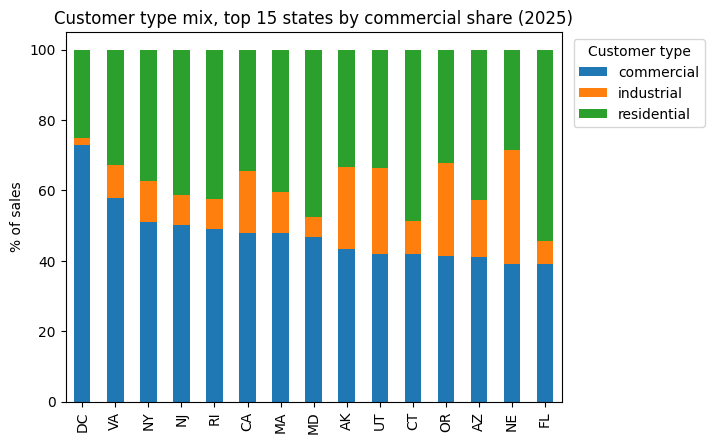

In [96]:
state_mix.sort_values("commercial", ascending=False).head(15).plot(kind="bar", stacked=True)
plt.title("Customer type mix, top 15 states by commercial share (2025)")
plt.xlabel("")
plt.ylabel("% of sales")
plt.legend(title="Customer type", bbox_to_anchor=(1.01, 1))
plt.show()